In [2]:
pip install torch torchvision tqdm timm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.0 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-1

In [3]:
import os
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import timm


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")


In [5]:
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])


In [6]:
batch_size = 32

train_dataset = ImageFolder(train_dir, transform=transform)
val_dataset = ImageFolder(val_dir, transform=transform)
test_dataset = ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


In [7]:
model = timm.create_model('efficientnet_b3', pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 5)  # 5 DR classes
model = model.to(device)


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [9]:
def train_model(model, train_loader, val_loader, epochs=30, patience=5, save_path='best_efficientnetb3.pth'):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    patience_counter = 0
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, verbose=True)

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            
       

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%\n")

    return history


In [10]:
def evaluate(model, loader, criterion):
    model.eval()
    correct, total, total_loss = 0, 0, 0.0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    avg_loss = total_loss / len(loader)
    return avg_loss, acc


In [11]:
history = train_model(model, train_loader, val_loader, epochs=30)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/30: 100%|██████████| 1088/1088 [07:10<00:00,  2.53it/s]



Epoch [1/30]
Train Loss: 0.9108, Train Acc: 61.18%
Val   Loss: 0.6955, Val   Acc: 70.59%



Epoch 2/30: 100%|██████████| 1088/1088 [07:10<00:00,  2.53it/s]



Epoch [2/30]
Train Loss: 0.6158, Train Acc: 73.76%
Val   Loss: 0.5551, Val   Acc: 75.75%



Epoch 3/30: 100%|██████████| 1088/1088 [07:10<00:00,  2.53it/s]


...


Epoch [28/30]
Train Loss: 0.0048, Train Acc: 99.86%
Val   Loss: 0.4580, Val   Acc: 90.05%



Epoch 29/30: 100%|██████████| 1088/1088 [07:11<00:00,  2.52it/s]



Epoch [29/30]
Train Loss: 0.0041, Train Acc: 99.89%
Val   Loss: 0.4543, Val   Acc: 90.29%



Epoch 30/30: 100%|██████████| 1088/1088 [07:11<00:00,  2.52it/s]



Epoch [30/30]
Train Loss: 0.0044, Train Acc: 99.87%
Val   Loss: 0.4543, Val   Acc: 90.47%



In [12]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 90.12%


In [13]:

pip install scikit-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model_metrics(model, loader, class_names):
    model.eval()
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds)
            y_probs.extend(probs)

    print("\n🔍 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("📊 Confusion Matrix")
    plt.show()

    try:
        y_true_onehot = np.eye(len(class_names))[y_true]
        auc = roc_auc_score(y_true_onehot, y_probs, multi_class="ovr")
        print(f"🔥 Macro AUC Score: {auc:.4f}")
    except:
        print("⚠️ ROC AUC skipped — requires one-hot true labels.")

    return y_true, y_pred, y_probs


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


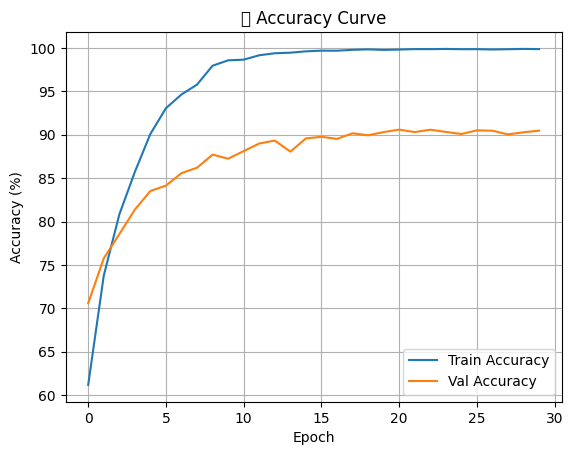

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


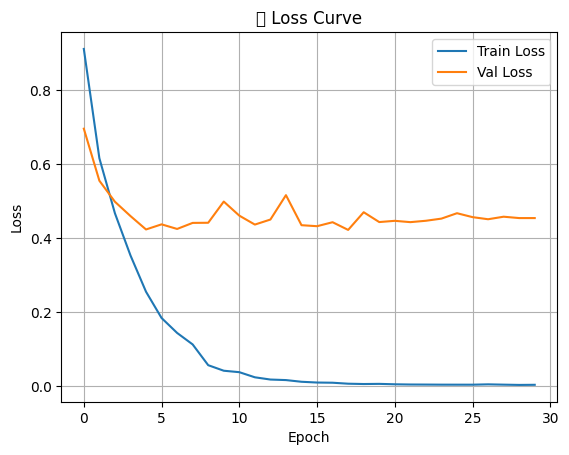

In [15]:
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('📈 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('📉 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()



🔍 Classification Report:
               precision    recall  f1-score   support

        No DR       0.82      0.76      0.78      1000
         Mild       0.85      0.93      0.89       971
     Moderate       0.83      0.80      0.82      1000
       Severe       0.98      1.00      0.99      1000
Proliferative       0.99      1.00      0.99      1000

     accuracy                           0.90      4971
    macro avg       0.89      0.90      0.89      4971
 weighted avg       0.89      0.90      0.89      4971



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


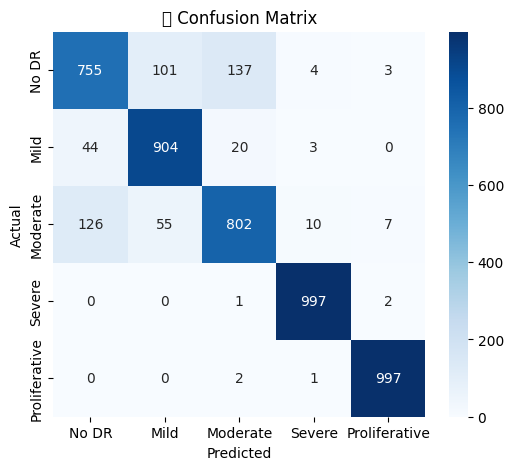

🔥 Macro AUC Score: 0.9846


In [16]:
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
y_true, y_pred, y_probs = evaluate_model_metrics(model, test_loader, class_names)


In [17]:
from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_true, y_pred))


Test Accuracy: 0.896197948098974


In [18]:
torch.save(model, 'dr_efficientnet_model.pth')  # full model
torch.save(model.state_dict(), 'dr_efficientnet_weights.pth')  # recommended


In [19]:
model = torch.load('dr_efficientnet_model.pth')
model.eval()


/tmp/ipykernel_31/1121239418.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('dr_efficientnet_model.pth')


EfficientNet(
  (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
        (bn1): BatchNormAct2d(
          40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(40, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b